# Feature Signal + Unsupervised Analysis

This notebook reads finalized pipeline outputs (CSV exports + caches) to ensure consistency and avoid leakage:

- Signal discovery on `X_train_imputed` with `y_train` (from `after1.5-train.csv` + `y_train.csv`)
- Unsupervised dimensionality reduction on sparse `X_train_ohe` via `TruncatedSVD` (from `X_train_ohe.csv`)

All model-fitting steps in this notebook use train artifacts only.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy import sparse
from scipy.sparse import issparse

from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

import os

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

if os.path.isdir("eda_insights_plots"):
    PLOTS_DIR = "eda_insights_plots"
else:
    PLOTS_DIR = os.path.join("eda_insights", "eda_insights_plots")

FIG_START = 6
os.makedirs(PLOTS_DIR, exist_ok=True)


def shorten_label(s: str, max_len: int = 34) -> str:
    s = str(s)
    if len(s) <= max_len:
        return s
    head = int(max_len * 0.65)
    tail = max_len - head - 1
    return f"{s[:head]}…{s[-tail:]}" if tail > 0 else f"{s[:max_len-1]}…"


def save_fig(
    fig,
    fig_num: int,
    title: str,
    subtitle: str | None = None,
    filename_stub: str | None = None,
    *,
    dpi: int = 200,
):
    """Save a matplotlib figure with standardized header + numbering."""
    prefix = f"fig{int(fig_num):02d}"
    if filename_stub:
        fname = f"{prefix}_{filename_stub}.png"
    else:
        safe = (
            title.lower()
            .replace(" ", "_")
            .replace("/", "-")
            .replace("(", "")
            .replace(")", "")
        )
        fname = f"{prefix}_{safe[:80]}.png"

    # Reserve a header band at the top (prevents overlap and keeps plots consistent)
    header_title_y = 0.975
    header_subtitle_y = 0.935
    header_bottom = 0.90 if subtitle else 0.92

    fig.suptitle(
        f"{title}",
        fontsize=16,
        fontweight="bold",
        y=header_title_y,
    )

    if subtitle:
        fig.text(0.01, header_subtitle_y, subtitle, fontsize=10, color="dimgray", va="top")

    fig.tight_layout(rect=[0, 0, 1, header_bottom])

    out_path = os.path.join(PLOTS_DIR, fname)
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    return out_path


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:

FORCE_RELOAD = True  # keeps results consistent with disk artifacts

def _sparse_has_nan(X) -> bool:
    try:
        return bool(np.isnan(X.data).any())
    except Exception:
        return False

if os.path.isdir("data"):
    DATA_DIR = "data"
else:
    DATA_DIR = os.path.join("..", "data")


def _p(name: str) -> str:
    return os.path.join(DATA_DIR, name)

# 1) Load targets
if FORCE_RELOAD or ("y_train" not in globals()):
    if os.path.exists(_p("y_train.csv")):
        _y = pd.read_csv(_p("y_train.csv"))
        y_train = (_y["target_y"] if "target_y" in _y.columns else _y.iloc[:, 0]).values
    elif os.path.exists(_p("train_ohe_with_y.csv")):
        _y = pd.read_csv(_p("train_ohe_with_y.csv"), usecols=["target_y"])
        y_train = _y["target_y"].values
    else:
        raise FileNotFoundError("Missing data/y_train.csv (or data/train_ohe_with_y.csv). Run data_prep.ipynb export cell first.")

# 2) Load X_train_imputed (post-imputation, pre-OHE)
if FORCE_RELOAD or ("X_train_imputed" not in globals()):
    if os.path.exists(_p("after1.5-train.csv")):
        X_train_imputed = pd.read_csv(_p("after1.5-train.csv"), index_col=0)
    else:
        raise FileNotFoundError("Missing data/after1.5-train.csv. Run data_prep.ipynb through 1.5 imputation.")

# 3) Load X_train_ohe (OHE feature matrix)
# Always reload to avoid stale in-kernel variables.
if FORCE_RELOAD or ("X_train_ohe" not in globals()) or (issparse(X_train_ohe) and _sparse_has_nan(X_train_ohe)):
    if os.path.exists(_p("X_train_ohe.csv")):
        X_train_ohe_df = pd.read_csv(_p("X_train_ohe.csv"))
        feat_names = np.array(X_train_ohe_df.columns)
        X_train_ohe_num = X_train_ohe_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        X_train_ohe = sparse.csr_matrix(X_train_ohe_num.to_numpy())
    elif os.path.exists(_p("train_ohe_with_y.csv")):
        df = pd.read_csv(_p("train_ohe_with_y.csv"))
        if "target_y" not in df.columns:
            raise ValueError("train_ohe_with_y.csv missing target_y column")
        X_train_ohe_df = df.drop(columns=["target_y"])
        feat_names = np.array(X_train_ohe_df.columns)
        X_train_ohe_num = X_train_ohe_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        X_train_ohe = sparse.csr_matrix(X_train_ohe_num.to_numpy())
    else:
        raise FileNotFoundError("Missing data/X_train_ohe.csv (or data/train_ohe_with_y.csv). Run data_prep.ipynb export cell first.")

# Optional: load test artifacts if present
if (FORCE_RELOAD or ("X_test_ohe" not in globals()) or (issparse(X_test_ohe) and _sparse_has_nan(X_test_ohe))) and os.path.exists(_p("X_test_ohe.csv")):
    X_test_ohe_df = pd.read_csv(_p("X_test_ohe.csv"))
    X_test_ohe_num = X_test_ohe_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    X_test_ohe = sparse.csr_matrix(X_test_ohe_num.to_numpy())

# Align target as a clean Series for association tests.
y_train_series = pd.Series(y_train).reset_index(drop=True)
if y_train_series.name is None:
    y_train_series.name = "target_y"

# Shape and type guardrails.
if X_train_imputed.shape[0] != len(y_train_series):
    raise ValueError("Row mismatch: X_train_imputed and y_train must align.")
if X_train_ohe.shape[0] != len(y_train_series):
    raise ValueError("Row mismatch: X_train_ohe and y_train must align.")

is_sparse_ohe = issparse(X_train_ohe)

numeric_cols = X_train_imputed.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_imputed.columns if c not in numeric_cols]

print("X_train_imputed shape:", X_train_imputed.shape)
print("X_train_ohe shape:", X_train_ohe.shape)
print("y_train length:", len(y_train_series))
print("X_train_ohe is sparse:", is_sparse_ohe)
print("Numeric columns in X_train_imputed:", len(numeric_cols))
print("Categorical columns in X_train_imputed:", len(cat_cols))
if "feat_names" in globals():
    print("OHE feature count:", len(feat_names))

X_train_imputed shape: (111992, 45)
X_train_ohe shape: (111992, 115)
y_train length: 111992
X_train_ohe is sparse: True
Numeric columns in X_train_imputed: 32
Categorical columns in X_train_imputed: 13
OHE feature count: 115


In [3]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramer's V for categorical association."""
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if valid.empty:
        return np.nan

    confusion = pd.crosstab(valid["x"], valid["y"])
    if confusion.empty or confusion.shape[0] < 2 or confusion.shape[1] < 2:
        return np.nan

    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = confusion.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((k_corr - 1), (r_corr - 1))
    if denom <= 0:
        return np.nan

    return float(np.sqrt(phi2_corr / denom))


def safe_pointbiserial(feature: pd.Series, target: pd.Series):
    valid = pd.DataFrame({"x": feature, "y": target}).dropna()
    if valid["x"].nunique() < 2:
        return np.nan, np.nan
    r, p = stats.pointbiserialr(valid["y"], valid["x"])
    return float(r), float(p)

Highly redundant numeric pairs (|Spearman| >= 0.8)


,feature_1,feature_2,spearman_corr,abs_corr
563,co-applicant_race_observed,co-applicant_sex_observed,0.998389,0.998389
497,co-applicant_ethnicity_observed,co-applicant_race_observed,0.998319,0.998319
499,co-applicant_ethnicity_observed,co-applicant_sex_observed,0.998062,0.998062
639,co-applicant_sex_observed,is_joint_application,-0.983711,0.983711
575,co-applicant_race_observed,is_joint_application,-0.983270,0.983270
511,co-applicant_ethnicity_observed,is_joint_application,-0.982864,0.982864
464,applicant_ethnicity_observed,applicant_race_observed,0.973265,0.973265
530,applicant_race_observed,applicant_sex_observed,0.967503,0.967503
466,applicant_ethnicity_observed,applicant_sex_observed,0.964747,0.964747
859,tract_owner_occupied_units,tract_one_to_four_family_homes,0.896086,0.896086


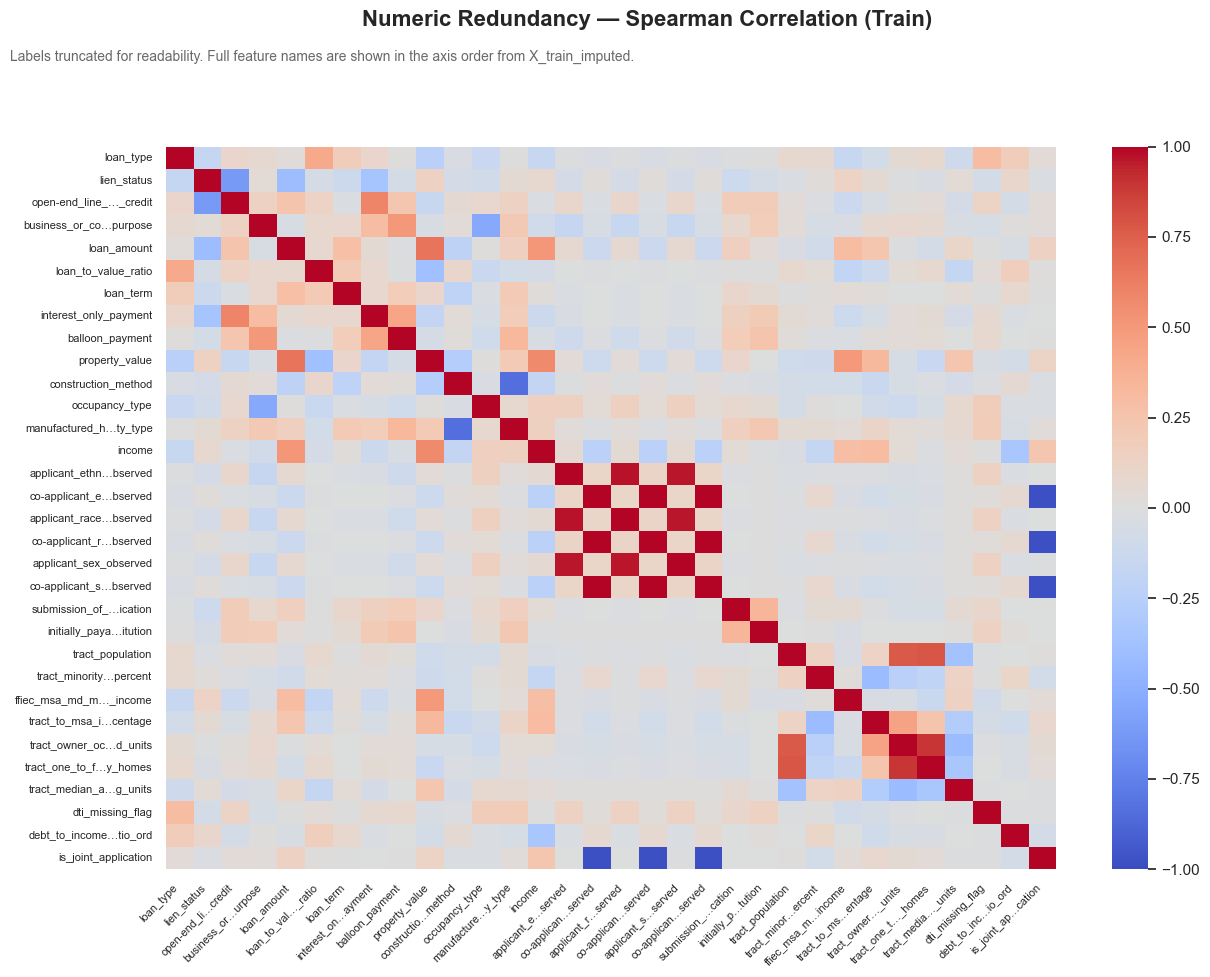

X_train_ohe columns: 115 | binary (0/1): 103 | continuous: 12
Continuous columns present in X_train_ohe (top by max):


,feature,min,max,mean,std
0,ffiec_msa_md_median_family_income,45900.000000,166600.000000,90837.044610,22440.838272
1,tract_population,0.000000,20758.000000,6020.532395,3284.714685
2,tract_one_to_four_family_homes,0.000000,6004.000000,1841.223909,1000.719424
3,tract_owner_occupied_units,0.000000,4882.000000,1349.954175,832.159793
4,loan_term,60.000000,361.000000,326.745812,70.178798
5,tract_to_msa_income_percentage,0.000000,273.046200,120.462402,48.323701
6,loan_to_value_ratio,13.873640,102.000000,70.604983,21.106775
7,tract_minority_population_percent,0.000000,98.330000,51.455663,24.995761
8,tract_median_age_of_housing_units,0.000000,76.000000,33.157788,17.954991
9,property_value,11.225257,15.111607,13.124826,0.735632


In [4]:
# 3) Numeric redundancy + correlation structure (X_train_imputed)

if numeric_cols:
    X_num = X_train_imputed[numeric_cols].apply(pd.to_numeric, errors="coerce")
    corr_spearman = X_num.corr(method="spearman")

    corr_long = (
        corr_spearman.where(np.triu(np.ones(corr_spearman.shape), k=1).astype(bool))
        .stack()
        .reset_index()
    )
    corr_long.columns = ["feature_1", "feature_2", "spearman_corr"]
    corr_long["abs_corr"] = corr_long["spearman_corr"].abs()

    high_corr_pairs = corr_long[corr_long["abs_corr"] >= 0.8].sort_values("abs_corr", ascending=False)

    print("Highly redundant numeric pairs (|Spearman| >= 0.8)")
    display(high_corr_pairs.head(30))

    # Make labels readable: shorten + rotate + smaller font.
    fig, ax = plt.subplots(figsize=(13, 10))
    sns.heatmap(corr_spearman, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title("")

    short_x = [shorten_label(c, 18) for c in corr_spearman.columns]
    short_y = [shorten_label(c, 22) for c in corr_spearman.index]
    ax.set_xticklabels(short_x, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(short_y, rotation=0, fontsize=8)

    save_fig(
        fig,
        6,
        "Numeric Redundancy — Spearman Correlation (Train)",
        subtitle="Labels truncated for readability. Full feature names are shown in the axis order from X_train_imputed.",
        filename_stub="numeric_redundancy_heatmap",
    )
    plt.show()
else:
    corr_spearman = pd.DataFrame()
    high_corr_pairs = pd.DataFrame(columns=["feature_1", "feature_2", "spearman_corr", "abs_corr"])
    print("No numeric columns available for redundancy check.")

# 4) One-hot matrix diagnostics (X_train_ohe)
# X_train_ohe contains BOTH binary OHE columns and continuous numeric columns.

if "X_train_ohe_df" in globals():
    _ohe_num = X_train_ohe_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    ohe_binary_cols = [
        c for c in _ohe_num.columns if set(pd.unique(_ohe_num[c])).issubset({0.0, 1.0})
    ]
    ohe_cont_cols = [c for c in _ohe_num.columns if c not in ohe_binary_cols]

    print(
        f"X_train_ohe columns: {len(_ohe_num.columns)} | binary (0/1): {len(ohe_binary_cols)} | continuous: {len(ohe_cont_cols)}"
    )

    if ohe_cont_cols:
        cont_stats = (
            _ohe_num[ohe_cont_cols]
            .agg(["min", "max", "mean", "std"])
            .T.sort_values("max", ascending=False)
            .reset_index()
            .rename(columns={"index": "feature"})
        )
        print("Continuous columns present in X_train_ohe (top by max):")
        display(cont_stats.head(25))


OHE-only: (111992, 103) | continuous: (111992, 12) | combined: (111992, 115)


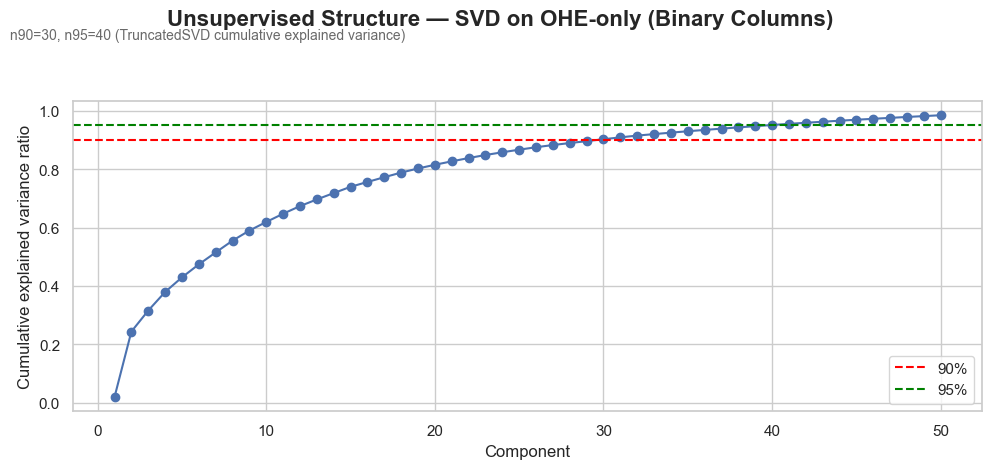

Unsupervised Structure — SVD on OHE-only (Binary Columns): n90=30, n95=40


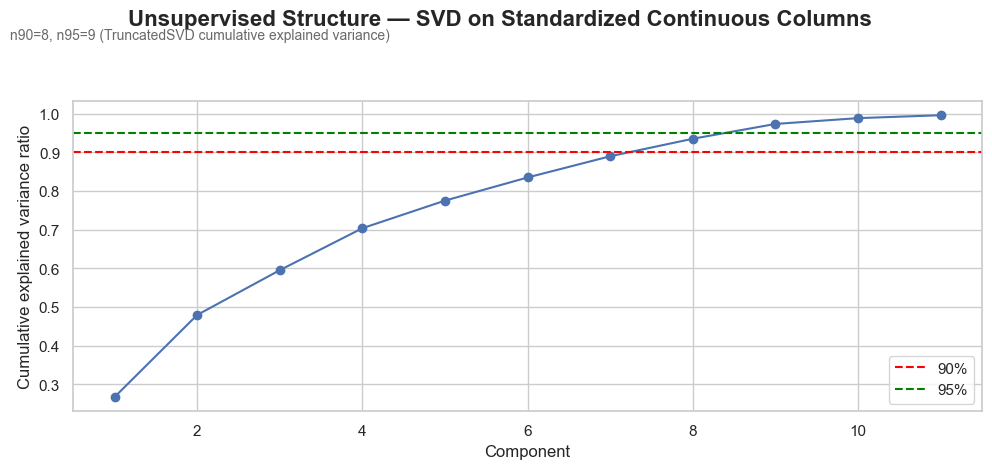

Unsupervised Structure — SVD on Standardized Continuous Columns: n90=8, n95=9


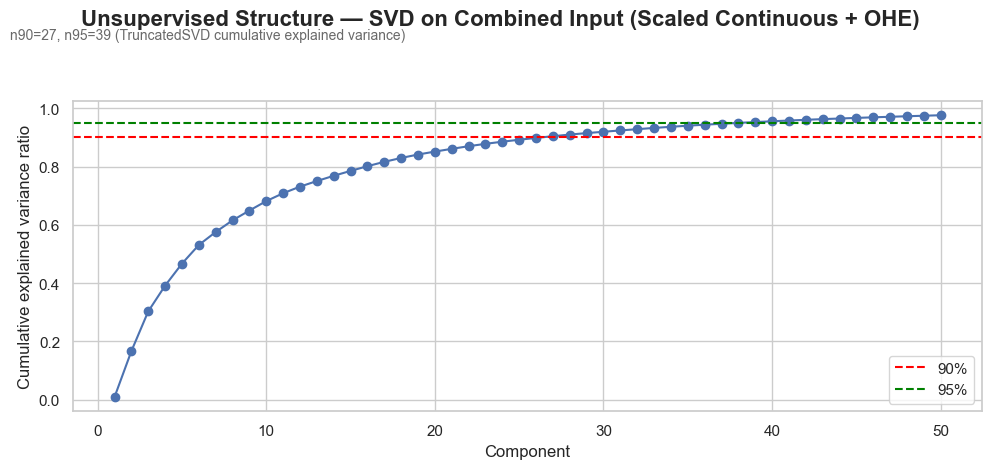

Unsupervised Structure — SVD on Combined Input (Scaled Continuous + OHE): n90=27, n95=39


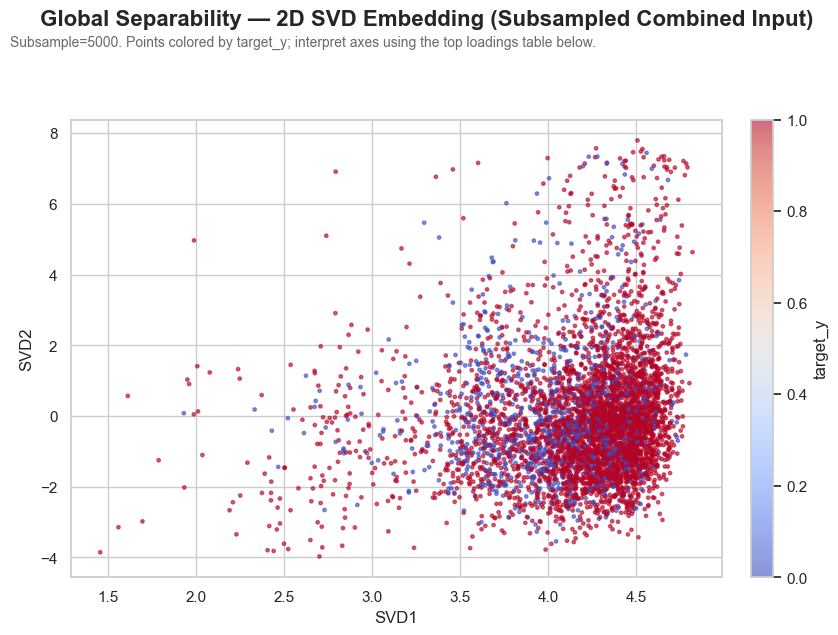

,component,feature,loading
0,SVD1,balloon_payment_2,0.233004
1,SVD1,manufactured_home_grouped_Not_Applicable_or_Ex...,0.230686
2,SVD1,derived_dwelling_category_Single Family (1-4 U...,0.229756
3,SVD1,manufactured_home_secured_property_type_3,0.228874
4,SVD1,business_or_commercial_purpose_2,0.226571
5,SVD1,applicant_ethnicity_observed_2,0.222376
6,SVD1,applicant_race_observed_2,0.222370
7,SVD1,applicant_sex_observed_2,0.222081
8,SVD1,interest_only_payment_2,0.221546
9,SVD1,conforming_loan_limit_C,0.221158


In [5]:
# 5) Unsupervised structure on model input (X_train_ohe)
# IMPORTANT: X_train_ohe is a MIX of:
# - binary one-hot columns (0/1)
# - continuous numeric columns (different scales)
# So we analyze them separately, then optionally combine for visualization.

if "X_train_ohe_df" not in globals():
    raise NameError("X_train_ohe_df missing. Re-run the loading cell.")

_ohe_num = X_train_ohe_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
_ohe_binary_cols = [c for c in _ohe_num.columns if set(pd.unique(_ohe_num[c])).issubset({0.0, 1.0})]
_ohe_cont_cols = [c for c in _ohe_num.columns if c not in _ohe_binary_cols]

X_ohe_only = sparse.csr_matrix(_ohe_num[_ohe_binary_cols].to_numpy())
X_cont = _ohe_num[_ohe_cont_cols].copy()

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont.to_numpy()) if X_cont.shape[1] else np.empty((X_ohe_only.shape[0], 0))
X_cont_scaled_sp = sparse.csr_matrix(X_cont_scaled) if X_cont_scaled.shape[1] else sparse.csr_matrix((X_ohe_only.shape[0], 0))

X_combined = sparse.hstack([X_cont_scaled_sp, X_ohe_only], format="csr")

print(f"OHE-only: {X_ohe_only.shape} | continuous: {X_cont.shape} | combined: {X_combined.shape}")


def _svd_summary(X, fig_num: int, short_title: str, max_components: int = 50):
    max_components = int(min(max_components, X.shape[0] - 1, X.shape[1] - 1))
    if max_components < 2:
        print(f"{short_title}: skipped (not enough dimensions)")
        return None, None, {"n90": None, "n95": None}

    svd_full = TruncatedSVD(n_components=max_components, random_state=42)
    if issparse(X) and np.isnan(X.data).any():
        raise ValueError(f"{short_title}: contains NaN")
    if (not issparse(X)) and np.isnan(X).any():
        raise ValueError(f"{short_title}: contains NaN")

    svd_full.fit(X)
    cum = np.cumsum(svd_full.explained_variance_ratio_)
    n90 = int(np.argmax(cum >= 0.90) + 1) if np.any(cum >= 0.90) else max_components
    n95 = int(np.argmax(cum >= 0.95) + 1) if np.any(cum >= 0.95) else max_components

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(range(1, len(cum) + 1), cum, marker="o")
    ax.axhline(0.90, color="red", linestyle="--", label="90%")
    ax.axhline(0.95, color="green", linestyle="--", label="95%")
    ax.set_xlabel("Component")
    ax.set_ylabel("Cumulative explained variance ratio")
    ax.legend(loc="lower right")

    save_fig(
        fig,
        fig_num,
        short_title,
        subtitle=f"n90={n90}, n95={n95} (TruncatedSVD cumulative explained variance)",
        filename_stub=f"svd_cumvar_{fig_num}",
    )
    plt.show()

    print(f"{short_title}: n90={n90}, n95={n95}")
    return svd_full, cum, {"n90": n90, "n95": n95}

svd_ohe, svd_ohe_cum, svd_ohe_meta = _svd_summary(
    X_ohe_only,
    7,
    "Unsupervised Structure — SVD on OHE-only (Binary Columns)",
)
svd_cont, svd_cont_cum, svd_cont_meta = _svd_summary(
    X_cont_scaled,
    8,
    "Unsupervised Structure — SVD on Standardized Continuous Columns",
)
svd_comb, svd_comb_cum, svd_comb_meta = _svd_summary(
    X_combined,
    9,
    "Unsupervised Structure — SVD on Combined Input (Scaled Continuous + OHE)",
)

# 2D embedding for intuition (subsample)
SUBSAMPLE = 5000
rng = np.random.default_rng(42)
idx = rng.choice(X_combined.shape[0], size=min(SUBSAMPLE, X_combined.shape[0]), replace=False)

svd2 = TruncatedSVD(n_components=2, random_state=42)
Z = svd2.fit_transform(X_combined[idx])

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sc = ax.scatter(
    Z[:, 0],
    Z[:, 1],
    c=y_train_series.iloc[idx].values,
    s=6,
    alpha=0.6,
    cmap="coolwarm",
)
ax.set_xlabel("SVD1")
ax.set_ylabel("SVD2")
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("target_y")

save_fig(
    fig,
    10,
    "Global Separability — 2D SVD Embedding (Subsampled Combined Input)",
    subtitle=f"Subsample={len(idx)}. Points colored by target_y; interpret axes using the top loadings table below.",
    filename_stub="svd2_embedding",
)
plt.show()

# Top loadings for interpretability (2D embedding)
svd_feature_names = np.array(list(_ohe_cont_cols) + list(_ohe_binary_cols))
loading_rows = []
for comp_idx, comp in enumerate(svd2.components_):
    top_idx = np.argsort(np.abs(comp))[::-1][:15]
    for j in top_idx:
        loading_rows.append(
            {
                "component": f"SVD{comp_idx+1}",
                "feature": svd_feature_names[j],
                "loading": float(comp[j]),
            }
        )

top_svd_loadings = pd.DataFrame(loading_rows)
display(top_svd_loadings)

# Keep compatibility names for downstream
svd_n90 = svd_comb_meta.get("n90")
svd_n95 = svd_comb_meta.get("n95")
X_train_svd = Z
X_test_svd = None


Top OHE features by lift (rate_when_on - base_rate)


,feature,support,rate_when_on,lift
0,derived_dwelling_category_Multifamily:Manufact...,0.000018,1.000000,0.203693
1,derived_dwelling_category_Multifamily:Site-Built,0.004768,0.932584,0.136277
2,initially_payable_to_institution_2,0.061531,0.901466,0.105159
3,debt_to_income_ratio_ord_36,0.026627,0.891348,0.095041
4,debt_to_income_ratio_ord_40,0.031708,0.890735,0.094428
5,aus_grouped_Standard_AUS,0.637421,0.889292,0.092985
6,debt_to_income_ratio_ord_41,0.033333,0.884811,0.088504
7,debt_to_income_ratio_ord_33,0.137867,0.884585,0.088279
8,debt_to_income_ratio_ord_44,0.040056,0.883638,0.087331
9,debt_to_income_ratio_ord_37,0.028466,0.882685,0.086378


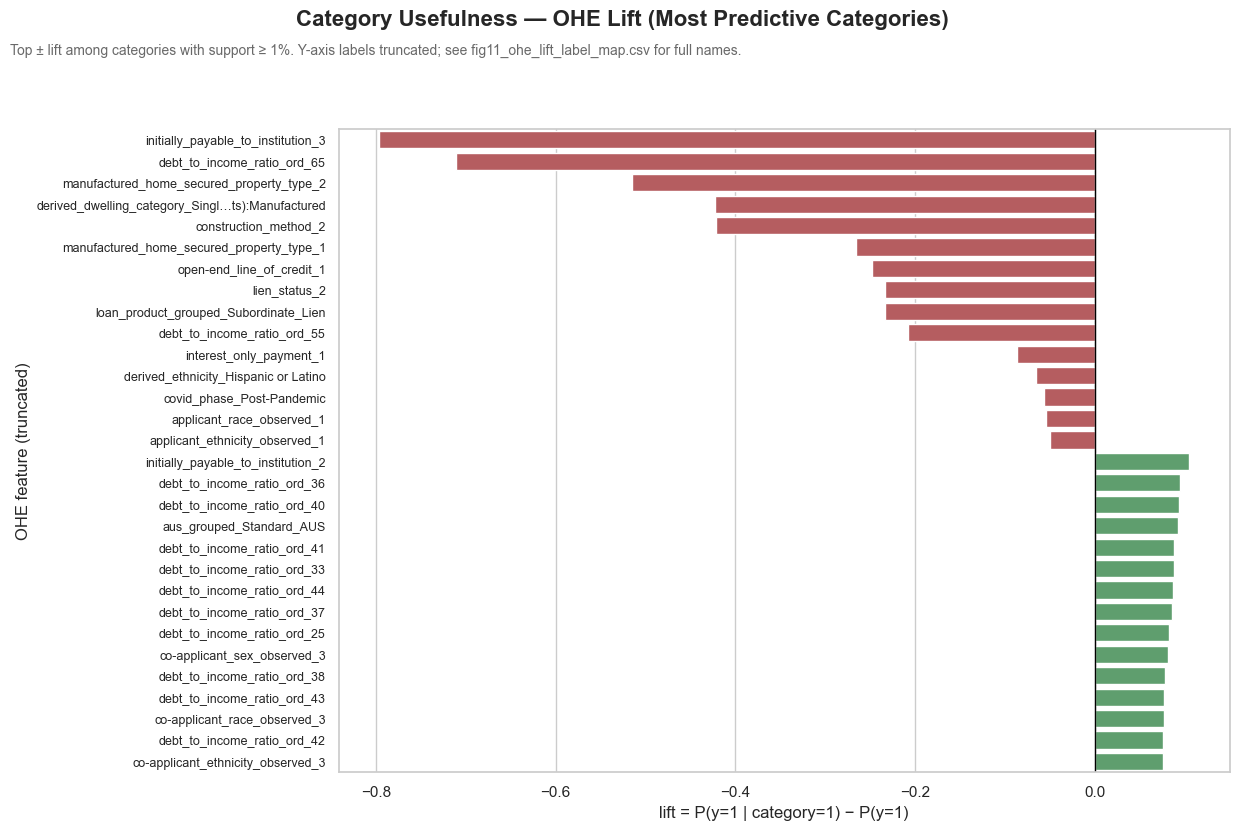

,high_corr_numeric_pairs_count,svd_combined_n90,svd_combined_n95,x_train_ohe_is_sparse,x_train_ohe_total_cols
0,11,27,39,True,115


Prepared modeling-focused EDA artifacts:
['high_corr_pairs', 'ohe_lift', 'top_svd_loadings', 'X_train_svd_2d', 'X_test_svd_2d']


In [6]:
# 7) Categorical usefulness (post-OHE): lift + support
# Goal: identify which categories are most associated with approval/rejection.

if "X_train_ohe_df" in globals():
    _ohe_num = X_train_ohe_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    _binary_cols = [c for c in _ohe_num.columns if set(pd.unique(_ohe_num[c])).issubset({0.0, 1.0})]

    base_rate = float(y_train_series.mean())
    rows = []

    for c in _binary_cols:
        x = _ohe_num[c].values
        support = float(x.mean())
        if support <= 0:
            continue
        rate_when_on = float(y_train_series[x == 1].mean()) if np.any(x == 1) else np.nan
        lift = rate_when_on - base_rate if pd.notna(rate_when_on) else np.nan
        rows.append({"feature": c, "support": support, "rate_when_on": rate_when_on, "lift": lift})

    ohe_lift = (
        pd.DataFrame(rows)
        .sort_values(["lift", "support"], ascending=False)
        .reset_index(drop=True)
    )

    print("Top OHE features by lift (rate_when_on - base_rate)")
    display(ohe_lift.head(30))

    # Plot both strongest positive-lift and negative-lift (with support threshold)
    MIN_SUPPORT = 0.01
    stable = ohe_lift[ohe_lift["support"] >= MIN_SUPPORT].copy()

    top_pos = stable.sort_values(["lift", "support"], ascending=False).head(15)
    top_neg = stable.sort_values(["lift", "support"], ascending=True).head(15)
    plot_df = pd.concat([top_neg, top_pos], axis=0)

    if not plot_df.empty:
        # Shorten long OHE feature names for plotting; also save a mapping for reference.
        plot_df = plot_df.copy()
        plot_df["feature_short"] = plot_df["feature"].map(lambda s: shorten_label(s, 48))

        label_map = (
            plot_df[["feature_short", "feature", "support", "lift"]]
            .drop_duplicates("feature_short")
            .sort_values("lift")
        )
        label_map.to_csv(os.path.join(PLOTS_DIR, "fig11_ohe_lift_label_map.csv"), index=False)

        fig, ax = plt.subplots(figsize=(12.5, 8.5))
        sns.barplot(
            data=plot_df,
            x="lift",
            y="feature_short",
            palette=["#C44E52"] * len(top_neg) + ["#55A868"] * len(top_pos),
            ax=ax,
        )
        ax.axvline(0, color="black", linewidth=1)
        ax.set_xlabel("lift = P(y=1 | category=1) − P(y=1)")
        ax.set_ylabel("OHE feature (truncated)")
        ax.tick_params(axis="y", labelsize=9)

        save_fig(
            fig,
            11,
            "Category Usefulness — OHE Lift (Most Predictive Categories)",
            subtitle=(
                f"Top ± lift among categories with support ≥ {MIN_SUPPORT:.0%}. "
                "Y-axis labels truncated; see fig11_ohe_lift_label_map.csv for full names."
            ),
            filename_stub="ohe_lift",
        )
        plt.show()
else:
    ohe_lift = pd.DataFrame(columns=["feature", "support", "rate_when_on", "lift"])

# 8) Modeling-focused handoff artifacts
recommendations = {
    "high_corr_numeric_pairs_count": int(len(high_corr_pairs)) if "high_corr_pairs" in globals() else 0,
    "svd_combined_n90": int(svd_n90) if "svd_n90" in globals() and svd_n90 is not None else None,
    "svd_combined_n95": int(svd_n95) if "svd_n95" in globals() and svd_n95 is not None else None,
    "x_train_ohe_is_sparse": bool(is_sparse_ohe),
    "x_train_ohe_total_cols": int(X_train_ohe.shape[1]) if "X_train_ohe" in globals() else None,
}

display(pd.DataFrame([recommendations]))

outputs = {
    "high_corr_pairs": high_corr_pairs,
    "ohe_lift": ohe_lift,
    "top_svd_loadings": top_svd_loadings,
    "X_train_svd_2d": X_train_svd,
    "X_test_svd_2d": X_test_svd,
}

print("Prepared modeling-focused EDA artifacts:")
print(list(outputs.keys()))
